In [ ]:
# Install and Import these libraries 
import os
import keras
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import keras 

from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from keras.layers import Dropout, Input, Activation , Rescaling

In [ ]:
# I have done this experimenting in kaggle but you guys can use other environment depending upon your use
# Just make sure to install all dependencies , Have a dedicated GPU and provide proper file path wherever asked

In [ ]:
# ===========================================================
# 1.  DATA LOADING FROM TRAIN AND TEST DIRECTORIES
# ===========================================================
train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/salader/dogsvscats/train',  # Place the directory location of training set here
    labels='inferred', 
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/salader/dogsvscats/test', # Place the directory location of testing set here
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)


In [ ]:
# # Apparently this code block is deprecated , we can use Rescalling directly in model building phase instead
# # ==========================================
# # 2. DATA PREPROCESSING (NORMALIZATION)
# # ==========================================
# # Normalize pixel values from [0, 255] to [0, 1]
# def process(image, label):
#     image = tf.cast(image / 255., tf.float32)
#     return image, label

# train_ds = train_ds.map(process)
# validation_ds = validation_ds.map(process)

In [ ]:
# ==========================================
# 4.Caching
# ==========================================

# This is an important step where we cache the data to avoid a huge toll on RAM by caching upto a specific amount only

# Optimize loading without saving the whole dataset to RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
# ==========================================
# 4. CNN MODEL ARCHITECTURE
# ==========================================
model = Sequential()
model.add(Input(shape=(256, 256, 3))) # 3 channels

model.add(Rescaling(1./255)) # Normalizing pixel values 

# For each block we are using maxpooling with constant param 
# Also added BatchNormalization so that model converges faster

# 1st Convolutional Block
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Convolutional Block
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Convolutional Block
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Flattening and Fully Connected Layers
model.add(Flatten()) # <--- Make sure to flatter our image to further process

# FCL Layer 1
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dropout(0.2))

# FCL Layer 2
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.2))

# Output Layer for Binary Classification
model.add(Dense(1))
model.add(Activation('sigmoid')) # <--- Using sigmoid cause we have a binary output 

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# ==========================================
# 5. MODEL COMPILATION & TRAINING
# ==========================================
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Execute training across 10 epochs
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10


I0000 00:00:1781308327.924195     525 service.cc:152] XLA service 0x7bc5b8026210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781308327.924254     525 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781308327.924261     525 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781308328.695990     525 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-12 23:52:12.462378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 23:52:12.772296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/625 ━━━━━━━━━━━━━━━━━━━━ 1:00 97ms/step - accuracy: 0.5781 - loss: 4.0483  

I0000 00:00:1781308337.252518     525 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 93ms/step - accuracy: 0.6043 - loss: 1.2160 - val_accuracy: 0.7004 - val_loss: 0.5828
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.7342 - loss: 0.5318 - val_accuracy: 0.7162 - val_loss: 0.5439
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.7869 - loss: 0.4599 - val_accuracy: 0.7954 - val_loss: 0.4412
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8151 - loss: 0.4153 - val_accuracy: 0.7584 - val_loss: 0.5540
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8491 - loss: 0.3483 - val_accuracy: 0.7776 - val_loss: 0.4944
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8836 - loss: 0.2715 - val_accuracy: 0.7532 - val_loss: 1.0118
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9215 - loss: 0.1949 - val_accuracy: 0.7492 - val_loss: 0.9310
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9433 - loss: 0.1478 - val_accurac

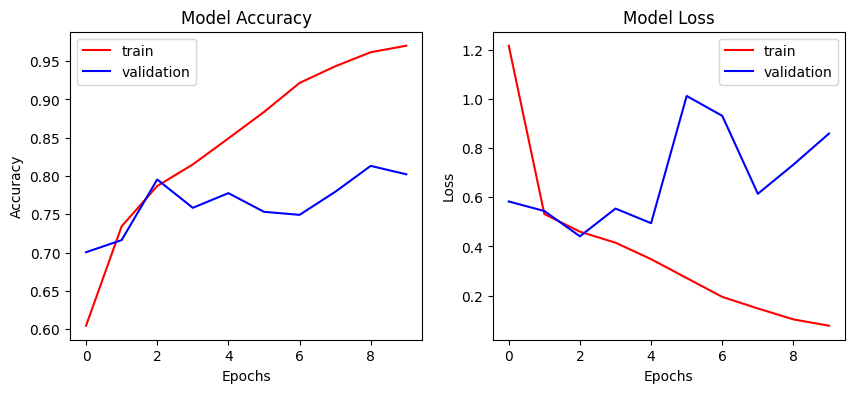

In [12]:
# ==========================================
# 6. EVALUATION (LOSS & ACCURACY PLOTS)
# ==========================================
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Processing: /kaggle/input/datasets/ayushdevadiga/test-1/NationalGeographic_2572187_16x9.avif


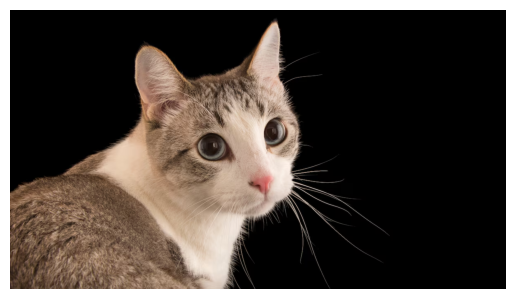

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Raw Prediction Value: 0.0044
Result: 🐱 It's a CAT!



In [26]:
# ==========================================
# 7. INFERENCE (PREDICTING ON NEW IMAGES)
# ==========================================

import os
import cv2
import matplotlib.pyplot as plt

# 1. Define a reusable function for inference
def predict_image(image_path, model):
    if not os.path.exists(image_path):
        print(f"❌ Image not found at: {image_path}\n")
        return

    test_img = cv2.imread(image_path)
    if test_img is None:
        print(f"❌ Error: Could not read image at: {image_path}\n")
        return

    print(f"Processing: {image_path}")
    
    # Visualise the image
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess (Resize & Reshape)
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale pixel values
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    raw_val = prediction[0][0]
    print(f"Raw Prediction Value: {raw_val:.4f}")

    if raw_val < 0.5:
        print("Result: 🐱 It's a CAT!\n")
    else:
        print("Result: 🐶 It's a DOG!\n")


# 2. Define the exact file paths from both directories
image_path_1 = '/kaggle/input/datasets/ayushdevadiga/test-1/NationalGeographic_2572187_16x9.avif'

# 3. Run predictions
predict_image(image_path_1, model)


In [27]:
# I have tried some other cases this model overfits and that is why it misclassifies a lot
# Next steps to improve this 

In [ ]:
''' 
Add higher Dropout value with more neurons
Data Augumentation
Early Stopping
Use Regularizers
'''